# 市场状态与策略失效归因

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_market_regime_analysis"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.width",
    180,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()


%load_ext autoreload
%autoreload 2

from market_regime_analysis import (
    analyze_batch_market_regimes,
    summarize_regime_performance,
    summarize_failure_attribution,
    summarize_timing_outcomes,
    create_regime_matrix,
    plot_regime_heatmap,
    plot_failure_decomposition,
)

from walk_forward_equity import (
    build_dynamic_schedule,
    build_fixed_schedule,
    build_continuous_stock_detail,
    build_portfolio,
    summarize_portfolio,
    summarize_annual_returns,
    build_equity_comparison,
    plot_equity_curves,
    plot_drawdown_curves,
    summarize_parameter_validation
)

from parameter_sensitivity import (
    build_ma_parameter_grid,
)

from walk_forward import (
    generate_walk_forward_windows,
    run_ma_walk_forward,
    run_fixed_parameter_validation,
    plot_walk_forward_metric,
    plot_selected_parameters
)

from backtest import (ma_cross_backtest,
                      backtest_plot_drawdown,
                      backtest_plot_nav,
                      backtest_plot_sbpoints,
                      calculate_performance,
                      calculate_buy_and_sell,
                      format_batch_summary,
                      run_batch_ma_backtest,
                      summarize_backtest_period,
                      run_ma_parameter_grid_search)

Matplotlib 中文字体： Microsoft YaHei


In [2]:
validation_stock_list = [
    "600028",  # 中国石化：石油石化
    "600276",  # 恒瑞医药：医药
    "600104",  # 上汽集团：汽车
    "600050",  # 中国联通：通信
    "601006",  # 大秦铁路：交通运输
    "600887",  # 伊利股份：食品乳业
    "600031",  # 三一重工：工程机械
    "600585",  # 海螺水泥：建筑材料
    "600900",  # 长江电力：公用事业
    "600570",  # 恒生电子：软件
]

validation_parameters = [
    (10, 40),  # 当前主要候选
    (20, 60),  # 原始基准
]

parameter_runs = {}

for fast_window, slow_window in validation_parameters:
    print(
        f"\n开始回测参数："
        f"{fast_window}/{slow_window}"
    )

    batch_summary, batch_results = (
        run_batch_ma_backtest(
            stock_list=validation_stock_list,
            fast_window=fast_window,
            slow_window=slow_window,
            commission_rate=0.0003,
            slippage_rate=0.0002,
            annual_risk_free_rate=0.0,
            trading_days=252,
            save_result=False,
        )
    )

    parameter_runs[
        (fast_window, slow_window)
    ] = {
        "summary": batch_summary,
        "results": batch_results,
    }


开始回测参数：10/40
正在回测：600028
正在回测：600276
正在回测：600104
正在回测：600050
正在回测：601006
正在回测：600887
正在回测：600031
正在回测：600585
正在回测：600900
正在回测：600570

开始回测参数：20/60
正在回测：600028
正在回测：600276
正在回测：600104
正在回测：600050
正在回测：601006
正在回测：600887
正在回测：600031
正在回测：600585
正在回测：600900
正在回测：600570


In [5]:
REGIME_CONFIG = {
    "trend_window": 60,
    "volatility_window": 20,
    "volatility_reference_window": 252,
    "volatility_reference_min_periods": 60,
    "efficiency_window": 20,
    "direction_threshold": 1.0,
    "efficiency_threshold": 0.35,
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
}

batch_results_10_40 = (
    parameter_runs[
        (10, 40)
    ]["results"]
)

batch_results_20_60 = (
    parameter_runs[
        (20, 60)
    ]["results"]
)

## 生成逐日状态明细

In [6]:
regime_detail_10_40 = (
    analyze_batch_market_regimes(
        batch_results=(
            batch_results_10_40
        ),
        **REGIME_CONFIG,
    )
)

regime_detail_20_60 = (
    analyze_batch_market_regimes(
        batch_results=(
            batch_results_20_60
        ),
        **REGIME_CONFIG,
    )
)

regime_detail_10_40[
    "ma_param"
] = "10/40"

regime_detail_20_60[
    "ma_param"
] = "20/60"

regime_detail = pd.concat(
    [
        regime_detail_10_40,
        regime_detail_20_60,
    ],
    ignore_index=True,
)

## 正确性测试

In [7]:
required_regime_columns = {
    "market_direction",
    "trend_quality",
    "volatility_state",
    "market_regime",
    "active_return",
    "timing_active_return",
    "missed_upside_return",
    "avoided_downside_return",
    "cost_drag_return",
    "timing_outcome",
}

missing_columns = (
    required_regime_columns
    - set(
        regime_detail.columns
    )
)

assert not missing_columns, (
    f"缺少字段：{missing_columns}"
)

print("状态字段检查通过")

assert np.allclose(
    regime_detail[
        "active_return"
    ],
    (
        regime_detail[
            "timing_active_return"
        ]
        + regime_detail[
            "cost_drag_return"
        ]
    ),
)

assert np.allclose(
    regime_detail[
        "timing_active_return"
    ],
    (
        regime_detail[
            "missed_upside_return"
        ]
        + regime_detail[
            "avoided_downside_return"
        ]
    ),
)

print("主动收益分解检查通过")

assert (
    regime_detail[
        "missed_upside_return"
    ] <= 0
).all()

assert (
    regime_detail[
        "avoided_downside_return"
    ] >= 0
).all()

assert (
    regime_detail[
        "cost_drag_return"
    ] <= 0
).all()

print("归因损益方向检查通过")

assert set(
    regime_detail[
        "market_direction"
    ].unique()
).issubset(
    {
        "up",
        "sideways",
        "down",
    }
)

assert set(
    regime_detail[
        "trend_quality"
    ].unique()
).issubset(
    {
        "trending",
        "choppy",
    }
)

assert set(
    regime_detail[
        "volatility_state"
    ].unique()
).issubset(
    {
        "high_vol",
        "low_vol",
    }
)

print("市场状态取值检查通过")



状态字段检查通过
主动收益分解检查通过
归因损益方向检查通过
市场状态取值检查通过


## 分析：整体失效来源

In [8]:
overall_failure = (
    summarize_failure_attribution(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
        ],
    )
)

display(
    overall_failure[
        [
            "ma_param",
            "active_return_sum",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "net_timing_benefit",
            "benefit_cost_ratio",
            "primary_failure_driver",
        ]
    ]
)



,ma_param,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio,primary_failure_driver
0,10/40,-5.1354,-2.5883,80.3750,75.5936,0.3540,-4.7814,0.9364,missed_upside
1,20/60,-3.9262,-1.4461,77.5713,73.8656,0.2205,-3.7057,0.9495,missed_upside


上述结果表明，策略失效来源是错过上涨，虽然最大回撤改善明显，但是不足以覆盖错过上涨的收益损失

In [9]:
timing_summary = (
    summarize_timing_outcomes(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
            "timing_outcome",
        ],
    )
)

display(
    timing_summary.sort_values(
        [
            "ma_param",
            "active_return_sum",
        ]
    )
)

,ma_param,timing_outcome,observation_count,stock_count,strategy_return_sum,benchmark_return_sum,active_return_sum,transaction_cost_sum,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,observation_rate
0,10/40,missed_upside,5172,10,-0.0785,80.3750,-80.4535,0.0785,-0.0000,0.0155,-0.0156,0.1112
2,10/40,suffered_downside,5905,10,-85.2124,-85.1219,-0.0905,0.0905,-0.0144,-0.0144,-0.0000,0.1270
3,10/40,captured_upside,5795,10,89.3167,89.3957,-0.0790,0.0790,0.0154,0.0154,-0.0000,0.1246
6,10/40,flat_market,1147,10,-0.0150,0.0000,-0.0150,0.0150,-0.0000,0.0000,-0.0000,0.0247
9,10/40,avoided_downside,5234,10,-0.0910,-75.5936,75.5026,0.0910,-0.0000,-0.0144,0.0144,0.1125
1,20/60,missed_upside,4974,10,-0.0535,77.5713,-77.6248,0.0535,-0.0000,0.0156,-0.0156,0.1070
4,20/60,captured_upside,5993,10,92.1419,92.1994,-0.0575,0.0575,0.0154,0.0154,-0.0000,0.1289
5,20/60,suffered_downside,6049,10,-86.8979,-86.8499,-0.0480,0.0480,-0.0144,-0.0144,-0.0000,0.1301
7,20/60,flat_market,1147,10,-0.0095,0.0000,-0.0095,0.0095,-0.0000,0.0000,-0.0000,0.0247
8,20/60,avoided_downside,5090,10,-0.0520,-73.8656,73.8136,0.0520,-0.0000,-0.0145,0.0145,0.1094


## 按市场状态分析

In [10]:
regime_summary = (
    summarize_regime_performance(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
            "market_direction",
            "trend_quality",
            "volatility_state",
        ],
    )
)

regime_columns = [
    "ma_param",
    "market_direction",
    "trend_quality",
    "volatility_state",
    "observation_count",
    "active_mean_daily_return",
    "conditional_strategy_sharpe",
    "conditional_active_information_ratio",
    "underperformance_rate",
    "average_position",
    "trade_event_count",
    "active_log_return_sum",
    "missed_upside_sum",
    "avoided_downside_sum",
    "cost_drag_sum",
]

display(
    regime_summary[
        regime_columns
    ].sort_values(
        [
            "ma_param",
            "active_log_return_sum",
        ]
    )
)

,ma_param,market_direction,trend_quality,volatility_state,observation_count,active_mean_daily_return,conditional_strategy_sharpe,conditional_active_information_ratio,underperformance_rate,average_position,trade_event_count,active_log_return_sum,missed_upside_sum,avoided_downside_sum,cost_drag_sum
0,10/40,down,choppy,high_vol,415,-0.0028,-1.2748,-1.5450,0.4819,0.0867,8,-0.9758,-4.2948,3.1562,-0.0040
1,10/40,sideways,choppy,high_vol,6869,-0.0003,0.1840,-0.2601,0.2514,0.5120,277,-0.9227,-28.6977,26.9130,-0.1385
3,10/40,sideways,trending,high_vol,1124,-0.0007,0.0959,-0.5528,0.2544,0.5249,26,-0.5671,-5.4719,4.6792,-0.0130
4,10/40,down,trending,high_vol,244,-0.0022,-1.0163,-1.1999,0.5164,0.0041,0,-0.4322,-2.7141,2.1804,0.0000
9,10/40,sideways,choppy,low_vol,6615,-0.0001,0.6379,-0.1412,0.2490,0.4934,244,-0.2319,-19.2358,18.6499,-0.1220
10,10/40,down,trending,low_vol,667,-0.0005,0.3946,-0.4055,0.5022,0.0180,4,-0.2076,-4.7958,4.4548,-0.0020
11,10/40,down,choppy,low_vol,1284,-0.0003,-0.5259,-0.2816,0.3925,0.1573,27,-0.2015,-6.6346,6.2757,-0.0135
12,10/40,up,trending,high_vol,815,-0.0001,-1.3965,-0.5707,0.0123,0.9816,5,-0.1137,-0.1861,0.0684,-0.0025
13,10/40,up,trending,low_vol,502,-0.0002,1.4383,-0.7480,0.0478,0.9303,3,-0.0950,-0.2593,0.1613,-0.0015
19,10/40,sideways,trending,low_vol,1537,0.0000,-0.4619,0.0277,0.2668,0.4626,29,0.1667,-4.8744,4.9239,-0.0145


找出最差市场状态

In [13]:
minimum_observations = 100
worst_regimes = (
    regime_summary.loc[
        regime_summary[
            "observation_count"
        ] >= minimum_observations
    ]
    .sort_values(
        "active_log_return_sum",
    )
)

display(
    worst_regimes[
        regime_columns
    ].head(10)
)

,ma_param,market_direction,trend_quality,volatility_state,observation_count,active_mean_daily_return,conditional_strategy_sharpe,conditional_active_information_ratio,underperformance_rate,average_position,trade_event_count,active_log_return_sum,missed_upside_sum,avoided_downside_sum,cost_drag_sum
0,10/40,down,choppy,high_vol,415,-0.0028,-1.2748,-1.5450,0.4819,0.0867,8,-0.9758,-4.2948,3.1562,-0.0040
1,10/40,sideways,choppy,high_vol,6869,-0.0003,0.1840,-0.2601,0.2514,0.5120,277,-0.9227,-28.6977,26.9130,-0.1385
2,20/60,down,choppy,high_vol,415,-0.0021,-1.1222,-1.1369,0.5012,0.0145,1,-0.7026,-4.5038,3.6153,-0.0005
3,10/40,sideways,trending,high_vol,1124,-0.0007,0.0959,-0.5528,0.2544,0.5249,26,-0.5671,-5.4719,4.6792,-0.0130
4,10/40,down,trending,high_vol,244,-0.0022,-1.0163,-1.1999,0.5164,0.0041,0,-0.4322,-2.7141,2.1804,0.0000
5,20/60,down,trending,high_vol,244,-0.0021,NaN,-1.1728,0.5164,0.0000,0,-0.4203,-2.7141,2.1922,0.0000
6,20/60,sideways,choppy,low_vol,6615,-0.0001,0.5976,-0.1784,0.2475,0.4827,131,-0.4179,-19.8042,18.9759,-0.0655
7,20/60,down,trending,low_vol,667,-0.0006,-0.4102,-0.4883,0.5022,0.0030,2,-0.2791,-4.9014,4.4852,-0.0010
8,20/60,sideways,trending,high_vol,1124,-0.0005,0.3248,-0.3487,0.2571,0.5160,53,-0.2707,-5.6916,5.1901,-0.0265
9,10/40,sideways,choppy,low_vol,6615,-0.0001,0.6379,-0.1412,0.2490,0.4934,244,-0.2319,-19.2358,18.6499,-0.1220


## 分维度观察

In [14]:
direction_summary = (
    summarize_regime_performance(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
            "market_direction",
        ],
    )
)

display(direction_summary)

,ma_param,market_direction,observation_count,stock_count,date_count,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,conditional_strategy_sharpe,conditional_benchmark_sharpe,conditional_active_information_ratio,strategy_win_rate,active_win_rate,underperformance_rate,average_position,trade_event_count,transaction_cost_sum,strategy_log_return_sum,benchmark_log_return_sum,active_log_return_sum,active_return_sum,missed_upside_sum,avoided_downside_sum,cost_drag_sum
0,10/40,down,2610,10,1240,-0.0002,0.0007,-0.0009,-0.5518,0.5185,-0.6928,0.0406,0.4161,0.4464,0.0962,39,0.0195,-0.5779,1.2392,-1.8171,-2.3917,-18.4393,16.0671,-0.0195
1,10/40,sideways,16145,10,2351,0.0002,0.0004,-0.0002,0.2673,0.3438,-0.2209,0.2395,0.2395,0.2521,0.5006,576,0.2880,2.2278,3.7828,-1.5550,-3.4018,-58.2798,55.1660,-0.2880
2,20/60,down,2610,10,1240,-0.0000,0.0007,-0.0007,-0.1139,0.5185,-0.5302,0.0080,0.4602,0.4732,0.0149,8,0.0040,-0.0396,1.2392,-1.2787,-1.8943,-19.5225,17.6322,-0.0040
3,20/60,sideways,16145,10,2351,0.0003,0.0004,-0.0001,0.3423,0.3438,-0.1508,0.2449,0.2362,0.2413,0.5114,410,0.2050,3.3067,3.7828,-0.4761,-2.3173,-57.3228,55.2105,-0.2050
4,20/60,up,4498,10,1660,0.0001,-0.0000,0.0001,0.0396,-0.0042,0.3161,0.4484,0.0165,0.0165,0.9675,23,0.0115,-0.9260,-1.2347,0.3087,0.2854,-0.7260,1.0229,-0.0115
5,10/40,up,4498,10,1660,0.0001,-0.0000,0.0001,0.1013,-0.0042,0.3121,0.4051,0.0625,0.0680,0.8746,93,0.0465,-0.4509,-1.2347,0.7838,0.6582,-3.6559,4.3605,-0.0465


In [15]:
quality_summary = (
    summarize_regime_performance(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
            "trend_quality",
        ],
    )
)

display(quality_summary)

,ma_param,trend_quality,observation_count,stock_count,date_count,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,conditional_strategy_sharpe,conditional_benchmark_sharpe,conditional_active_information_ratio,strategy_win_rate,active_win_rate,underperformance_rate,average_position,trade_event_count,transaction_cost_sum,strategy_log_return_sum,benchmark_log_return_sum,active_log_return_sum,active_return_sum,missed_upside_sum,avoided_downside_sum,cost_drag_sum
0,10/40,choppy,18364,10,2350,0.0003,0.0005,-0.0002,0.3192,0.3642,-0.1947,0.2539,0.2284,0.2369,0.5274,641,0.3205,3.4549,4.7943,-1.3394,-3.2683,-62.0733,59.1256,-0.3205
1,10/40,trending,4889,10,1937,-0.0003,0.0001,-0.0004,-0.2911,0.0456,-0.3814,0.2317,0.2125,0.2436,0.5279,67,0.0335,-2.2560,-1.0070,-1.2489,-1.8671,-18.3017,16.4681,-0.0335
2,20/60,choppy,18364,10,2350,0.0003,0.0005,-0.0001,0.3505,0.3642,-0.1587,0.2625,0.2189,0.2185,0.5471,293,0.1465,4.0350,4.7943,-0.7593,-2.6015,-59.2994,56.8444,-0.1465
3,20/60,trending,4889,10,1937,-0.0002,0.0001,-0.0003,-0.1912,0.0456,-0.2662,0.2397,0.2189,0.2438,0.5318,148,0.0740,-1.6939,-1.0070,-0.6868,-1.3246,-18.2719,17.0212,-0.0740


In [16]:
volatility_summary = (
    summarize_regime_performance(
        regime_detail=regime_detail,
        group_columns=[
            "ma_param",
            "volatility_state",
        ],
    )
)

display(volatility_summary)

,ma_param,volatility_state,observation_count,stock_count,date_count,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,conditional_strategy_sharpe,conditional_benchmark_sharpe,conditional_active_information_ratio,strategy_win_rate,active_win_rate,underperformance_rate,average_position,trade_event_count,transaction_cost_sum,strategy_log_return_sum,benchmark_log_return_sum,active_log_return_sum,active_return_sum,missed_upside_sum,avoided_downside_sum,cost_drag_sum
0,10/40,high_vol,11227,10,2176,-0.0000,0.0004,-0.0004,-0.0126,0.2244,-0.3471,0.2732,0.2006,0.2176,0.5817,356,0.1780,-2.0444,0.4909,-2.5353,-4.0969,-42.5247,38.6058,-0.1780
1,20/60,high_vol,11227,10,2176,0.0001,0.0004,-0.0003,0.0854,0.2244,-0.2418,0.2892,0.1875,0.1945,0.6127,203,0.1015,-0.8042,0.4909,-1.2951,-2.8139,-40.0138,37.3014,-0.1015
2,20/60,low_vol,12026,10,2176,0.0003,0.0004,-0.0001,0.4408,0.3876,-0.1160,0.2283,0.2481,0.2512,0.4796,238,0.1190,3.1453,3.2963,-0.1510,-1.1123,-37.5575,36.5642,-0.1190
3,10/40,low_vol,12026,10,2176,0.0003,0.0004,-0.0001,0.4551,0.3876,-0.1070,0.2268,0.2480,0.2576,0.4770,352,0.1760,3.2433,3.2963,-0.0530,-1.0385,-37.8504,36.9879,-0.1760


## 绘制热力图

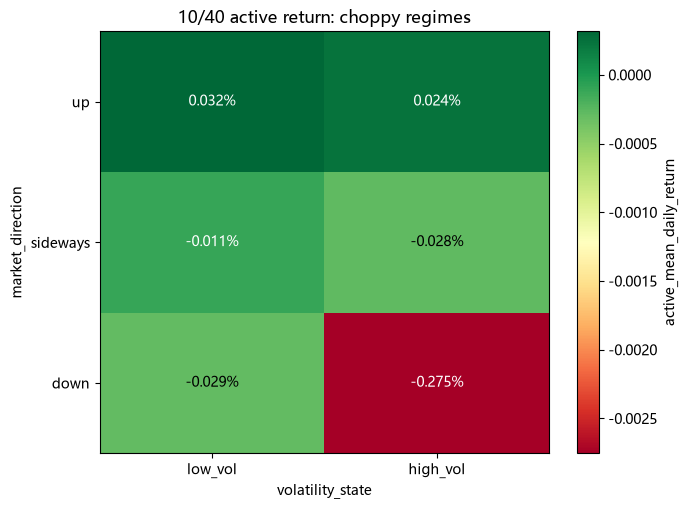

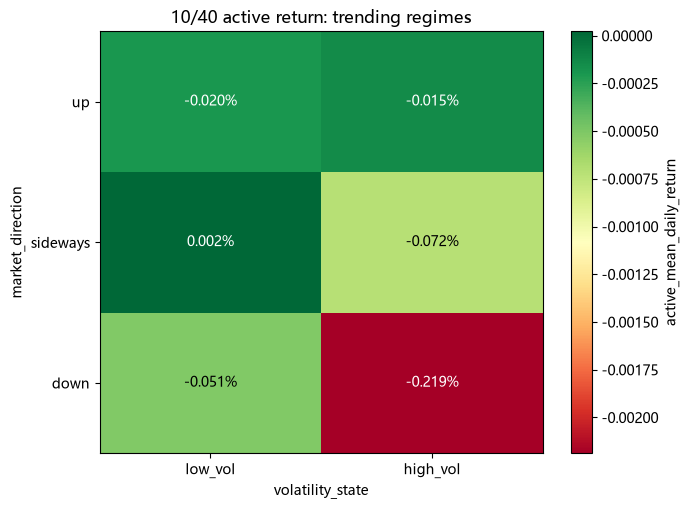

In [20]:
regime_summary_10_40 = (
    regime_summary.loc[
        regime_summary[
            "ma_param"
        ] == "10/40"
    ]
)

fig_choppy, ax_choppy = (
    plot_regime_heatmap(
        regime_summary=(
            regime_summary_10_40
        ),
        value_column=(
            "active_mean_daily_return"
        ),
        filters={
            "trend_quality": "choppy",
        },
        value_format=".3%",
        title=(
            "10/40 active return: "
            "choppy regimes"
        ),
    )
)

plt.show()

fig_trending, ax_trending = (
    plot_regime_heatmap(
        regime_summary=(
            regime_summary_10_40
        ),
        value_column=(
            "active_mean_daily_return"
        ),
        filters={
            "trend_quality": "trending",
        },
        value_format=".3%",
        title=(
            "10/40 active return: "
            "trending regimes"
        ),
    )
)

plt.show()

### 按股票分析

In [21]:
stock_failure = (
    summarize_failure_attribution(
        regime_detail=(
            regime_detail
        ),
        group_columns=[
            "ma_param",
            "symbol",
        ],
    )
)

display(
    stock_failure.sort_values(
        [
            "ma_param",
            "active_log_return_sum",
        ]
    )
)

,ma_param,symbol,observation_count,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio,missed_upside_days,avoided_downside_days,captured_upside_days,suffered_downside_days,primary_failure_driver
1,10/40,600887,2328,-0.8395,-0.5873,8.5120,7.7055,0.0330,-0.8065,0.9018,541,547,601,601,missed_upside
2,10/40,600104,2332,-0.8181,-0.5774,8.6152,7.8331,0.0360,-0.7821,0.9054,578,582,526,581,missed_upside
3,10/40,600585,2352,-0.7731,-0.5305,8.5547,7.8191,0.0375,-0.7356,0.9100,543,565,591,615,missed_upside
4,10/40,600028,2352,-0.6090,-0.4802,5.7663,5.1953,0.0380,-0.5710,0.8951,493,441,556,564,missed_upside
7,10/40,600900,2233,-0.3712,-0.3181,3.5094,3.1721,0.0340,-0.3372,0.8952,393,386,698,646,missed_upside
9,10/40,600050,2257,-0.4867,-0.2254,8.3994,7.9476,0.0350,-0.4517,0.9423,545,596,406,493,missed_upside
10,10/40,601006,2352,-0.3267,-0.1943,5.3353,5.0436,0.0350,-0.2917,0.9392,499,475,557,563,missed_upside
12,10/40,600031,2351,-0.4383,-0.1058,9.3414,8.9376,0.0345,-0.4038,0.9532,502,526,628,627,missed_upside
16,10/40,600276,2351,-0.2128,0.0516,8.2547,8.0743,0.0325,-0.1803,0.9743,484,495,698,647,missed_upside
18,10/40,600570,2345,-0.2599,0.3790,14.0867,13.8653,0.0385,-0.2214,0.9816,594,621,534,568,missed_upside


In [22]:
stock_failure_10_40 = (
    stock_failure.loc[
        stock_failure[
            "ma_param"
        ] == "10/40"
    ]
)

display(
    stock_failure_10_40[
        [
            "symbol",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "net_timing_benefit",
            "benefit_cost_ratio",
            "missed_upside_days",
            "avoided_downside_days",
            "primary_failure_driver",
        ]
    ]
)

,symbol,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio,missed_upside_days,avoided_downside_days,primary_failure_driver
1,600887,-0.5873,8.5120,7.7055,0.0330,-0.8065,0.9018,541,547,missed_upside
2,600104,-0.5774,8.6152,7.8331,0.0360,-0.7821,0.9054,578,582,missed_upside
3,600585,-0.5305,8.5547,7.8191,0.0375,-0.7356,0.9100,543,565,missed_upside
4,600028,-0.4802,5.7663,5.1953,0.0380,-0.5710,0.8951,493,441,missed_upside
7,600900,-0.3181,3.5094,3.1721,0.0340,-0.3372,0.8952,393,386,missed_upside
9,600050,-0.2254,8.3994,7.9476,0.0350,-0.4517,0.9423,545,596,missed_upside
10,601006,-0.1943,5.3353,5.0436,0.0350,-0.2917,0.9392,499,475,missed_upside
12,600031,-0.1058,9.3414,8.9376,0.0345,-0.4038,0.9532,502,526,missed_upside
16,600276,0.0516,8.2547,8.0743,0.0325,-0.1803,0.9743,484,495,missed_upside
18,600570,0.3790,14.0867,13.8653,0.0385,-0.2214,0.9816,594,621,missed_upside


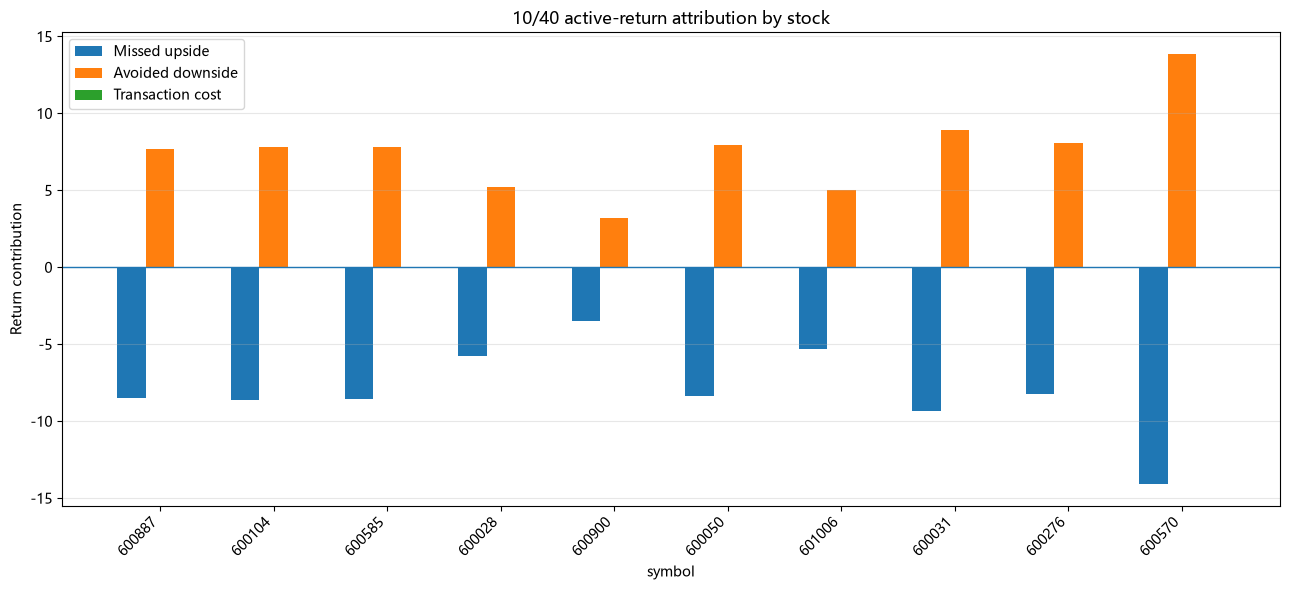

In [23]:
fig_failure, ax_failure = (
    plot_failure_decomposition(
        failure_summary=(
            stock_failure_10_40
        ),
        label_column="symbol",
        title=(
            "10/40 active-return "
            "attribution by stock"
        ),
    )
)

plt.show()

### 按年份分析

In [24]:
annual_failure = (
    summarize_failure_attribution(
        regime_detail=(
            regime_detail
        ),
        group_columns=[
            "ma_param",
            "year",
        ],
    )
)

display(
    annual_failure.sort_values(
        [
            "year",
            "ma_param",
        ]
    )
)

,ma_param,year,observation_count,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio,missed_upside_days,avoided_downside_days,captured_upside_days,suffered_downside_days,primary_failure_driver
10,10/40,2015,1522,-0.6925,0.0514,13.1858,12.5188,0.0255,-0.6670,0.9476,427,399,304,355,missed_upside
17,20/60,2015,1522,0.2288,0.9212,11.9886,12.2309,0.0135,0.2423,1.0191,412,398,319,356,none
16,10/40,2016,2413,0.5997,0.8862,7.2524,7.8856,0.0335,0.6332,1.0823,474,470,636,638,none
14,20/60,2016,2413,-0.0155,0.2768,7.6792,7.6822,0.0185,0.0030,0.9980,479,458,631,650,missed_upside
2,10/40,2017,2339,-1.4105,-1.3180,4.7681,3.3925,0.0350,-1.3755,0.7063,371,312,806,694,missed_upside
5,20/60,2017,2339,-0.9618,-0.8884,3.5432,2.6024,0.0210,-0.9408,0.7301,277,247,900,759,missed_upside
8,10/40,2018,2430,-0.8586,-0.5591,10.4555,9.6354,0.0385,-0.8201,0.9182,638,625,536,536,missed_upside
9,20/60,2018,2430,-0.3657,-0.0490,10.4826,10.1413,0.0245,-0.3412,0.9652,638,632,536,529,missed_upside
1,10/40,2019,2440,-1.4536,-1.3230,6.0429,4.6242,0.0350,-1.4186,0.7608,459,380,768,707,missed_upside
0,20/60,2019,2440,-1.6008,-1.5006,5.5582,3.9809,0.0235,-1.5773,0.7132,442,369,785,718,missed_upside


In [25]:
annual_failure_10_40 = (
    annual_failure.loc[
        annual_failure[
            "ma_param"
        ] == "10/40"
    ]
)

display(
    annual_failure_10_40[
        [
            "year",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "benefit_cost_ratio",
        ]
    ]
)

,year,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,benefit_cost_ratio
1,2019,-1.3230,6.0429,4.6242,0.0350,0.7608
2,2017,-1.3180,4.7681,3.3925,0.0350,0.7063
4,2020,-0.9246,7.3689,6.3164,0.0375,0.8528
6,2024,-0.8149,6.8015,5.8598,0.0380,0.8568
8,2018,-0.5591,10.4555,9.6354,0.0385,0.9182
10,2015,0.0514,13.1858,12.5188,0.0255,0.9476
11,2023,0.0853,6.4591,6.4411,0.0355,0.9918
13,2021,0.2249,9.6103,9.5977,0.0405,0.9945
16,2016,0.8862,7.2524,7.8856,0.0335,1.0823
19,2022,1.1036,8.4307,9.3220,0.0350,1.1011


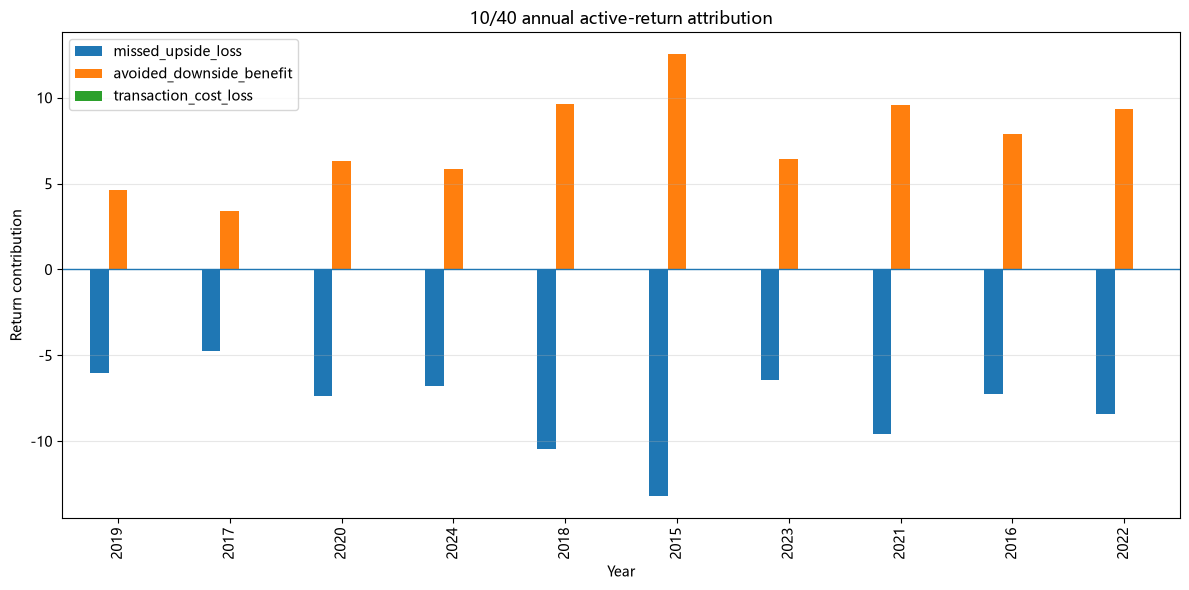

In [26]:
annual_plot = (
    annual_failure_10_40
    .set_index("year")
    [
        [
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
        ]
    ]
    .copy()
)

annual_plot[
    "missed_upside_loss"
] *= -1

annual_plot[
    "transaction_cost_loss"
] *= -1

ax = annual_plot.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Return contribution"
)

ax.set_title(
    "10/40 annual active-return attribution"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

## 整体比较

In [27]:
parameter_comparison = (
    overall_failure[
        [
            "ma_param",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "benefit_cost_ratio",
            "primary_failure_driver",
        ]
    ]
)

display(parameter_comparison)

,ma_param,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,benefit_cost_ratio,primary_failure_driver
0,10/40,-2.5883,80.3750,75.5936,0.3540,0.9364,missed_upside
1,20/60,-1.4461,77.5713,73.8656,0.2205,0.9495,missed_upside


In [28]:
regime_pair_comparison = (
    regime_summary.pivot_table(
        index=[
            "market_direction",
            "trend_quality",
            "volatility_state",
        ],
        columns="ma_param",
        values=(
            "active_mean_daily_return"
        ),
    )
    .reset_index()
)

regime_pair_comparison[
    "10_40_minus_20_60"
] = (
    regime_pair_comparison[
        "10/40"
    ]
    - regime_pair_comparison[
        "20/60"
    ]
)

display(
    regime_pair_comparison.sort_values(
        "10_40_minus_20_60",
        ascending=False,
    )
)

ma_param,market_direction,trend_quality,volatility_state,10/40,20/60,10_40_minus_20_60
9,up,choppy,low_vol,0.0003,0.0001,0.0002
8,up,choppy,high_vol,0.0002,0.0001,0.0002
3,down,trending,low_vol,-0.0005,-0.0006,0.0001
5,sideways,choppy,low_vol,-0.0001,-0.0001,0.0000
2,down,trending,high_vol,-0.0022,-0.0021,-0.0000
7,sideways,trending,low_vol,0.0000,0.0001,-0.0000
4,sideways,choppy,high_vol,-0.0003,-0.0001,-0.0001
11,up,trending,low_vol,-0.0002,-0.0000,-0.0002
10,up,trending,high_vol,-0.0001,0.0001,-0.0002
1,down,choppy,low_vol,-0.0003,-0.0001,-0.0002


## 保存结果

In [29]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

regime_detail.to_csv(
    REPORT_DIR
    / "market_regime_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

overall_failure.to_csv(
    REPORT_DIR
    / "overall_failure_attribution.csv",
    index=False,
    encoding="utf-8-sig",
)

timing_summary.to_csv(
    REPORT_DIR
    / "timing_outcome_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_summary.to_csv(
    REPORT_DIR
    / "market_regime_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_failure.to_csv(
    REPORT_DIR
    / "stock_failure_attribution.csv",
    index=False,
    encoding="utf-8-sig",
)

annual_failure.to_csv(
    REPORT_DIR
    / "annual_failure_attribution.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_pair_comparison.to_csv(
    REPORT_DIR
    / "parameter_regime_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

fig_choppy.savefig(
    REPORT_DIR
    / "10_40_choppy_regime_heatmap.png",
    dpi=160,
    bbox_inches="tight",
)

fig_trending.savefig(
    REPORT_DIR
    / "10_40_trending_regime_heatmap.png",
    dpi=160,
    bbox_inches="tight",
)

fig_failure.savefig(
    REPORT_DIR
    / "10_40_stock_failure_attribution.png",
    dpi=160,
    bbox_inches="tight",
)

## 市场状态与策略失效归因结论

### 1. 总体失效来源

- 10/40 的错过上涨损失：80.3750	
- 10/40 的规避下跌收益：75.5936
- 10/40 的交易成本损失：0.3540
- benefit_cost_ratio：0.9364	
- 主要失效来源：missed_upside

### 2. 趋势方向

- 上涨状态中的主动收益：0.0001	
- 横盘状态中的主动收益：-0.0002	
- 下跌状态中的主动收益：-0.0009	
- 策略是否主要依靠规避下跌产生价值：是

### 3. 趋势质量

- trending 状态表现：-1.2489	
- choppy 状态表现：-1.3394	
- 震荡行情是否为主要失效环境：否
- 交易成本是否主要发生在 choppy 状态：是

### 4. 波动状态

- 高波动状态表现：-2.5353	
- 低波动状态表现：-0.0530	
- 高波动下是否规避更多下跌：否
- 是否在高波动反弹中错过更多上涨：是

### 5. 跨股票失效

- 错过上涨最严重的股票：600570
- 规避下跌收益最高的股票：600570
- 交易成本最高的股票：都差不多
- 是否多数股票具有相同失效原因：是，全为错过上涨

### 6. 10/40 与 20/60

- 10/40 优势主要来自哪些状态：avoided_downside_benefit
- 20/60 是否规避更多下跌：否
- 10/40 是否减少了错过上涨：否
- 两者结构性差异是否明显：否，两者失效原因类似以及在不同市场环境下的表现类似

### 7. 当前判断

- 双均线策略是否只具有风险控制价值：是
- 失效是否主要来自震荡行情：否
- 失效是否主要来自上涨反弹中的空仓：是
- 是否值得进入市场状态过滤研究：

## 市场状态与策略失效归因结论

固定参数 `10/40` 的主要失效来源是错过上涨。策略通过空仓规避下跌获得了较明显的正向收益，但该收益不足以覆盖空仓期间错过上涨所造成的损失。交易成本占比较低，因此交易成本和频繁交易不是当前策略失效的主要原因。

策略在 trending 和 choppy 环境中均未表现出明显的稳定优势，说明失效不能简单归因于震荡行情。高波动状态对整体负主动收益的贡献最大，而低波动状态接近中性。结合错过上涨损失较大的结果，策略很可能在高波动下跌后的快速反弹阶段，因为均线确认滞后而长时间保持空仓。

`10/40` 与 `20/60` 的失效结构基本一致。`10/40` 能够规避略多的下跌，但并未明显减少错过上涨，说明单纯改变均线窗口无法解决策略的结构性滞后问题。

因此，当前不建议直接进入宽泛的市场状态过滤研究。简单过滤震荡或高波动状态可能同时删除策略有效的下跌保护阶段。下一阶段更适合研究高波动反弹中的再入场问题，包括离场后的空仓持续时间、错过上涨发生的时间分布、短期反转特征以及分级仓位和快速再入场机制。

本轮使用的外部验证股票不再用于优化新规则。新的再入场机制应首先在原开发样本中设计和冻结，再使用新的股票或未参与研究的未来数据进行验证。
